# Seminar: Deep Learning
At the seminar on PyTorch we trained an MLP for classification of MINIST digits.


```python
net = torch.nn.Sequential(
    torch.nn.Linear(input_size, hidden_dim_size, bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim_size, number_of_classes, bias=True)
)
```

This simple neural network architecture worked pretty well on MNIST.
At this seminar, we will try solving the same problem of 10-class classification of small pictures for another dataset --- CIFAR-10.


In contrast to MNIST, this dataset won't be that easy to classify for our MLP, so we will need to use some deep learning trickery to make it better.
![](https://github.com/adasegroup/ML2020_seminars/raw/master/seminar13/img/cifar.png)

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from IPython import display


def get_accuracy(model, dataloader, device):
    correct = 0
    with torch.inference_mode():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            prediction = model(x).argmax(dim=-1, keepdim=True)#сделал предсказание по оси классов dim=-1([num_objects, num_classes]), keepdim = True сохранил вид как объекты подавались argmax ->
            #[B, num_classes] dim=-1  значит по num_classes
            #[
            #[0.2, 1.7, -0.4],   # объект 0
            #[1.1, 0.3,  0.5]    # объект 1
            #]
            # с keepdim=True
            #[[1],
            #[0]]       shape = [B, 1]
            # без keepdim=True
            # argmax -> [1, 0]      shape = [B]
            correct += prediction.eq(y.view_as(prediction)).sum().item()
            #prediction: [B, 1]   например [[1],[0],[1]]
            #y:          [B]      например [1, 1, 1]
            #y.view_as(prediction) -> [B,1] -> [[1],[1],[1]]
            #prediction: [[1],[0],[1]]
            #y:          [[1],[1],[1]]
            #eq ->        [[T],[F],[T]]
            #[[T],[F],[T]] -> sum = 2
            #Преобразует тензор-число в обычный Python int
            #Добавляет число правильных предсказаний этого батча в общий счётчик за эпоху/прогон
    return correct / len(dataloader.dataset)


class Monitor:
    def __init__(self):
        if hasattr(tqdm.tqdm, "_instances"):
            [*map(tqdm.tqdm._decr_instances, list(tqdm.tqdm._instances))]

        self.learning_curve = []
        self.train_accuracy_curve = []
        self.val_accuracy_curve = []
        self.best_val_accuracy = 0
        self.best_val_epoch = 0

    def add_loss_value(self, value):
        self.learning_curve.append(value)

    def add_train_accuracy_value(self, value):
        self.train_accuracy_curve.append(value)

    def add_val_accuracy_value(self, value):
        self.val_accuracy_curve.append(value)

        if value > self.best_val_accuracy:
            self.best_val_accuracy = value
            self.best_val_epoch = len(self.val_accuracy_curve)

    def show(self):
        display.clear_output(wait=True)
        f, axes = plt.subplots(1, 2, figsize=(15, 3))
        axes[0].set_title("Loss")
        axes[0].plot(self.learning_curve)

        last_train_accuracy = self.train_accuracy_curve[-1]
        last_val_accuracy = self.val_accuracy_curve[-1]
        best_val_accuracy = self.best_val_accuracy
        best_val_accuracy = self.best_val_accuracy

        axes[1].set_title(
            f"Train {last_train_accuracy:.4f}, val {last_val_accuracy:.4f}, "
            f"max val {self.best_val_accuracy:.4f} at {self.best_val_epoch}"
        )
        axes[1].plot(self.train_accuracy_curve)
        axes[1].plot(self.val_accuracy_curve)

        plt.tight_layout()
        plt.show()


def set_random_seeds(seed_value=0, device="cpu"):
    """source https://forums.fast.ai/t/solved-reproducibility-where-is-the-randomness-coming-in/31628/5"""
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    if device != "cpu":
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader
from tqdm import trange

## 1. Intro
Let's recall that training a neural network is mainly based on four elements:
* what we train on, i.e the data,
* what we train, i.e the architecture of the neural network,
* how we measure the training performance, i.e the loss function,
* and how we update the weights of the neural network, i.e the optimizer.

If your network performs bad, these are the four things that you want to change.
Today we will be looking only at three of them, and we will keep the loss function the same.

We will use [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss), as in the seminar on PyTorch.
```python
loss_function = torch.nn.CrossEntropyLoss()
```

### The data: PyTorch Dataset and DataLoader
For working with data, PyTorch provides convenient functionality concentrated around classes [Dataset](https://pytorch.org/docs/stable/data.html?highlight=dataset#torch.utils.data.Dataset) and [DataLoader](https://pytorch.org/docs/stable/data.html?highlight=dataset#torch.utils.data.DataLoader).
It also has a library called [torchvision](https://pytorch.org/vision/stable/index.html) with predefined classes for popular computer vision datasets.

For example, we can use [torchvision.datasets.MNIST](https://pytorch.org/vision/stable/datasets.html#mnist)
or [torchvision.datasets.CIFAR10](https://pytorch.org/vision/stable/datasets.html#cifar):
we specify the directory in which the dataset will be located, indicate that we want to download it, and that we want to select the training subset.

In [ ]:
mnist_train = torchvision.datasets.MNIST("./mnist", download=True, train=True)
cifar_train = torchvision.datasets.CIFAR10("./cifar", download=True, train=True)

Files already downloaded and verified


Then we can, basically, use these instances as lists of pairs input-target.

In [ ]:
print(len(mnist_train))
input_image, target_class = mnist_train[1005]
print(target_class)
input_image

60000
9


In [ ]:
type(input_image)

PIL.Image.Image

50000
7


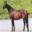

In [ ]:
print(len(cifar_train))
input_image, target_class = cifar_train[25131]
print(target_class)
input_image

To convert input images from `PIL.Image` to` torch.Tensor`, we can use the `transform` parameter.

In [ ]:
# torchvision.datasets.

In [ ]:
mnist_train = torchvision.datasets.MNIST(
    "./mnist", train=True, transform=torchvision.transforms.ToTensor()
)# перевод в тензор transform=torchvision.transforms.ToTensor()
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, transform=torchvision.transforms.ToTensor()
)

input_tensor, target_class = cifar_train[0]
input_tensor.shape

torch.Size([3, 32, 32])

количество каналов x высота x ширина

In [ ]:
input_tensor

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [ ]:
target_class

6

In [ ]:
for image, target_class in mnist_train:
    print(image.shape, target_class)
    break

torch.Size([1, 28, 28]) 5


In the seminar on PyTorch we saw that PyTorch Modules can process batches of input indepdendently and in parallel.
To combine the samples into batches, we can use [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html?highlight=dataset#torch.utils.data.DataLoader).

We initialize it with the dataset, set the batch size,
and also can set the number of parallel processes that will be loading and processing the data with `num_workers`,
and can specify that we want to randomly shuffle the data.

батч=64 семпла

In [ ]:
# class Dataset()
# def __getitem__(self, index):

#   x  = f(self.element[index])
#   return x

In [ ]:
train_loader = torch.utils.data.DataLoader(
    mnist_train, batch_size=64, num_workers=4, shuffle=True
)#batch_size=64, num_workers=4 num_workers как корень из batch_size, shuffle=True

Then we can iterate over the batches in the loader.

In [ ]:
for batch_i, (input_tensor, target_class) in enumerate(train_loader):
    print(batch_i)
    print(input_tensor.shape, target_class.shape)
    print(target_class[:5])
    break

0
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([6, 5, 4, 1, 7])


### The architechture: PyTorch Module
We will start with the same architecture that we had at the seminar on PyTorch:
```python
torch.nn.Sequential(
    torch.nn.Linear(input_size, hidden_dim_size, bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim_size, number_of_classes, bias=True)
)
```

This architecture expects the input of shape `[**, input_size]`,
where `**` are batch dimensions and `input_size` is an integer,
so we need to reshape each input image of shape `[channels_n, height, width]` into a 1D array with `channels_n * height * width` elements.

For incapsulation of things like this reshape, PyTorch has a base class [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module).

So, let's make a class `MLP` which inherits from `torch.nn.Module`.
We pass to the constructor the size of the input image from which we calculate the `input_size` of the first linear block and we store the sequence of all blocks in the `mlp` attribute.
When we call `model(input)`, the method `forward` is used internally, so we reshape the input in this method.

In [ ]:
class MLP(torch.nn.Module):  # Multi-layer perceptron
    def __init__(self, input_image_size, hidden_dim_size, number_of_classes):
        r"""
        Parameters
        ----------
        input_image_size : iterable of int
            (channels_n, height, width) # [1,28,28] - MNIST
        hidden_dim_size : int
        number_of_classes : int
        """
        super().__init__()

        input_size = input_image_size[0] * input_image_size[1] * input_image_size[2]
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(input_size, hidden_dim_size),
            torch.nn.ReLU(),  # - > no init
            torch.nn.Linear(hidden_dim_size, number_of_classes),
        )

    def forward(self, x):
        r"""
        Parameters
        ----------
        x : torch.Tensor
            of shape [batch_size, channels_n, height, width]

        Returns
        -------
        y : torch.Tensor
            of shape [batch_size, classes_n]
        """
        batch_size = len(x)
        x = x.reshape(batch_size, -1)  # b, c * h * w
        return self.mlp(x)

In [ ]:
inputs, targets = next(iter(train_loader))
inputs.shape

torch.Size([64, 1, 28, 28])

In [ ]:
targets[11]

tensor(3)

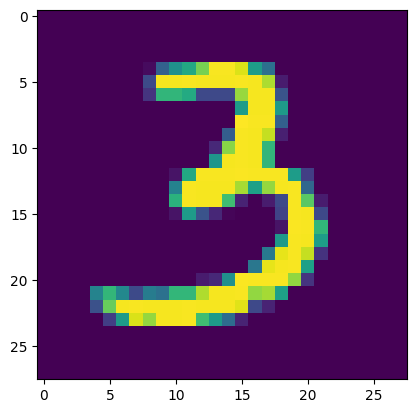

In [ ]:
plt.imshow(inputs[11].squeeze(0))

In [ ]:
model = MLP(input_image_size=[1, 28, 28], hidden_dim_size=80, number_of_classes=10)

In [ ]:
model

MLP(
  (mlp): Sequential(
    (0): Linear(in_features=784, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=10, bias=True)
  )
)

Default weight initialization for nn.Linear:
https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/linear.py#L109

Default weight initialization for nn.Conv2d:
https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/conv.py#L147

In [ ]:
nn_outputs = model(inputs)
nn_outputs.shape
# Glorot \ Xavier initialization (see doc. )

torch.Size([64, 10])

In [ ]:
nn_outputs[0]

tensor([-0.0193,  0.1728,  0.0231, -0.0514, -0.0070,  0.1071,  0.0181, -0.0250,
        -0.0463,  0.0917], grad_fn=<SelectBackward0>)

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.0188,  0.0005,  0.0339,  ..., -0.0253,  0.0009, -0.0353],
         [ 0.0111, -0.0259,  0.0002,  ..., -0.0190, -0.0268,  0.0213],
         [-0.0095, -0.0331, -0.0352,  ...,  0.0110,  0.0313,  0.0286],
         ...,
         [-0.0017,  0.0234,  0.0019,  ...,  0.0100,  0.0332, -0.0204],
         [-0.0123, -0.0176,  0.0343,  ..., -0.0180, -0.0123, -0.0325],
         [-0.0351,  0.0212,  0.0324,  ..., -0.0066, -0.0289, -0.0217]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0016, -0.0100,  0.0241, -0.0292,  0.0293, -0.0259,  0.0331, -0.0283,
          0.0099, -0.0223, -0.0277,  0.0185,  0.0136,  0.0163, -0.0185,  0.0256,
          0.0213, -0.0081, -0.0119,  0.0119,  0.0257, -0.0268, -0.0027, -0.0199,
         -0.0300,  0.0288,  0.0117, -0.0249, -0.0298,  0.0332,  0.0025, -0.0341,
         -0.0007,  0.0066,  0.0257, -0.0106,  0.0036,  0.0298, -0.0202,  0.0281,
          0.0126,  0.0001, -0.0053,  0.0184, -0.0041,  0.0146,  0.0081, -0.0177

### The optimizer
We will start with Gradient Descent with momentum as our baseline.
```python
torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
```
We can access the parameters of the model with `model.parameters()`, as before:
it will collect the parameters from all attributes of the model that are also `torch.nn.Module`.

In [ ]:
# torch.optim.Adam()

#### Gradient Descent vs Stochastic Gradient Descent vs Mini-Batch Gradient Descent
At the seminar on PyTorch, we calculated the outputs of the neural network in parallel for the entire dataset, averaged the loss over the entire dataset and updated the network parameters w.r.t this average.
This variant of Gradient Descent is called just Gradient Descent or Batch Gradient Descent.
```python
# all_inputs.shape == [dataset_size, input_size]
optimizer.zero_grad()
output = model(all_inputs)
loss = loss_f(output, all_targets)
loss.backward()
optimizer.step()
```

Real-world datasets are rather large, so parallel computation on the whole dataset is inefficient in memory.
Therefore, there is another well-established variant called Stochastic Gradient Descent.
In this variant, we select samples in random order one at a time, calculate the model output and the loss w.r.t only this single sample and update the weights
```python
for input, target in data:
    # input.shape == [1, input_size]
    optimizer.zero_grad()
    output = model(input)
    loss = loss_f(output, target)
    loss.backward()
    optimizer.step()
```

Doing calculations in parallel for multiple samples is usually more efficient in time than in cycle for a single sample.
So in practice, a combination of these two variants, called Mini-Batch Gradient Descent, is used.
Here, we take the samples not one at a time but in batches of several samples
```python
for input_batch, target_batch in data:
    # input_batch.shape == [batch_size, input_size];  1 < batch_size < dataset_size
    optimizer.zero_grad()
    output = model(input_batch)
    loss = loss_f(output, target_batch)
    loss.backward()
    optimizer.step()
```
The optimal batch size is chosen experimentally; good values for today's seminar are in range 64-512.

In [ ]:
torch.nn.CrossEntropyLoss()

CrossEntropyLoss()

### Training procedure

In [ ]:
!nvidia-smi

Thu Nov 14 16:23:44 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB           Off| 00000000:3B:00.0 Off |                    0 |
| N/A   32C    P0               34W / 250W|   1434MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
torch.cuda.is_available()

True

In [ ]:
# we choose the device that we will work on --- GPU or CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=1,
    plot_each=1,
):
    # send the model to that device
    model = model.to(device)
    # initialize some visualization code that you don't need to care about
    monitor = Monitor()
    # one full cycle on train data is called epoch
    for epoch in trange(epochs_n):
        # switch the model to the train mode
        # later on we will have some modules that function differently in train and test mode
        model.train()
        for model_input, target in train_loader:
            # send data to device
            model_input = model_input.to(device)
            target = target.to(device)
            # calculate outputs and loss
            model_output = model(model_input)
            loss = loss_function(model_output, target)
            # update model weights
            optimizer.zero_grad()
            loss.backward()
            # model.linear_layer1.weight.grad -
            optimizer.step()
            # do some visualization
            monitor.add_loss_value(loss.item())

        # evaluate the model
        # switch the model to the test mode
        model.eval()

        train_accuracy = get_accuracy(model, train_loader, device)
        val_accuracy = get_accuracy(model, val_loader, device)

        monitor.add_train_accuracy_value(train_accuracy)
        monitor.add_val_accuracy_value(val_accuracy)

        if epoch % plot_each == 0:
            monitor.show()

Now, let's put everything together and try to train an `MLP` classifier first on MNIST then on CIFAR-10.

#### MNIST

In [ ]:
loss_function = torch.nn.CrossEntropyLoss()

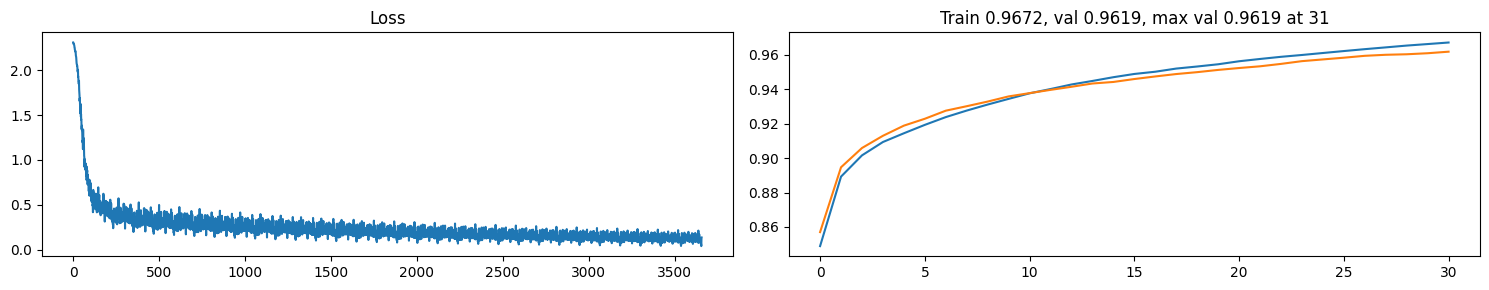

100%|██████████| 31/31 [02:23<00:00,  4.63s/it]


In [ ]:
set_random_seeds(device=device)

mnist_train = torchvision.datasets.MNIST(
    "./mnist", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

mnist_val = torchvision.datasets.MNIST(
    "./mnist", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
batch_size = 512

train_loader = torch.utils.data.DataLoader(
    mnist_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    mnist_val, batch_size=batch_size, num_workers=4
)

model = MLP([1, 28, 28], 100, 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

train(model, optimizer, loss_function, train_loader, val_loader, device, epochs_n=31)

лосс на уровне батчей визуализируем, плато еще нет можно было еще пообучать

#### CIFAR

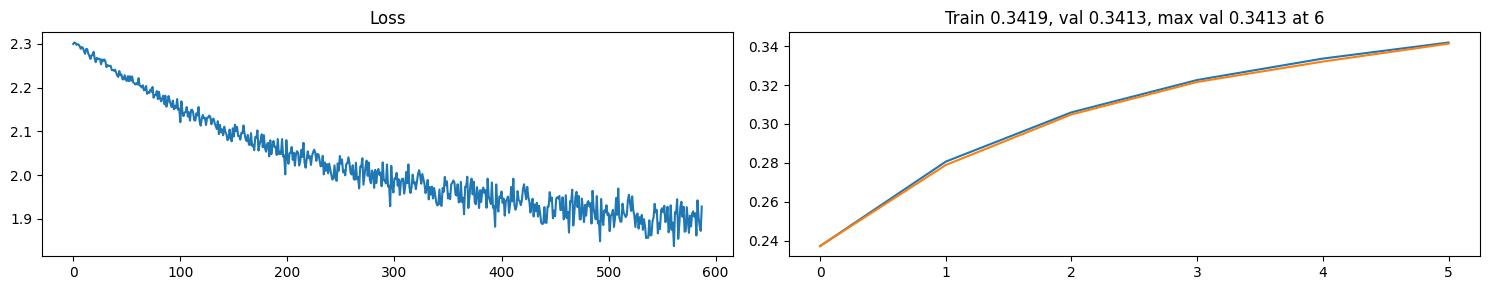

100%|██████████| 6/6 [00:28<00:00,  4.76s/it]


In [ ]:
set_random_seeds(device=device)

cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=torchvision.transforms.ToTensor()
)
cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

model = MLP([3, 32, 32], 1000, 10)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

train(model, optimizer, loss_function, train_loader, val_loader, device, epochs_n=6)

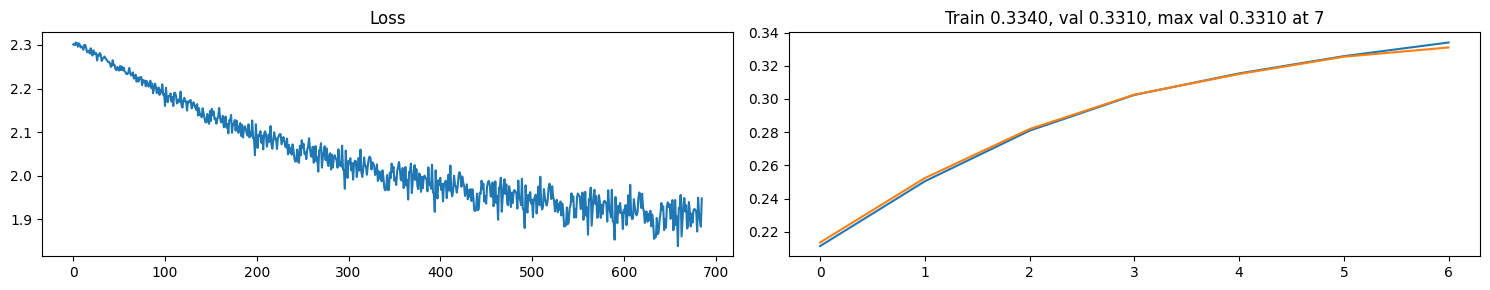

100%|██████████| 7/7 [00:33<00:00,  4.83s/it]


In [ ]:
set_random_seeds(device=device)

cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=torchvision.transforms.ToTensor()
)
cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

model = MLP([3, 32, 32], 100, 10)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

train(model, optimizer, loss_function, train_loader, val_loader, device, epochs_n=7)

We see two things.
First, training neural networks on real datasets can take quite a lot of time, although in this example it is still very fast.
Second, while on MNIST our MLP achieves 90% accuracy in a minute of training and without overfitting,
on CIFAR the accuracy is significantly lower.

In this seminar we will try different deep learning techniques to get better performance at CIFAR classification.
We will look at these techniques on MNIST and then you will try them for CIFAR.

надо попробовать другой lr

Как проверить несходимость на однной батче, ниже

# One batch overfit

In [ ]:
cifar_train.data.shape

(50000, 32, 32, 3)

In [ ]:
cifar_train_ob = torchvision.datasets.CIFAR10(
    "./cifar", train=True, transform=torchvision.transforms.ToTensor()
)

In [ ]:
cifar_train_ob.data.shape

(50000, 32, 32, 3)

In [ ]:
cifar_train_ob.data = cifar_train_ob.data[:512, :, :, :]# до первого батча

In [ ]:
cifar_train_ob.__len__()

512

In [ ]:
cifar_train_ob.data.shape

(512, 32, 32, 3)

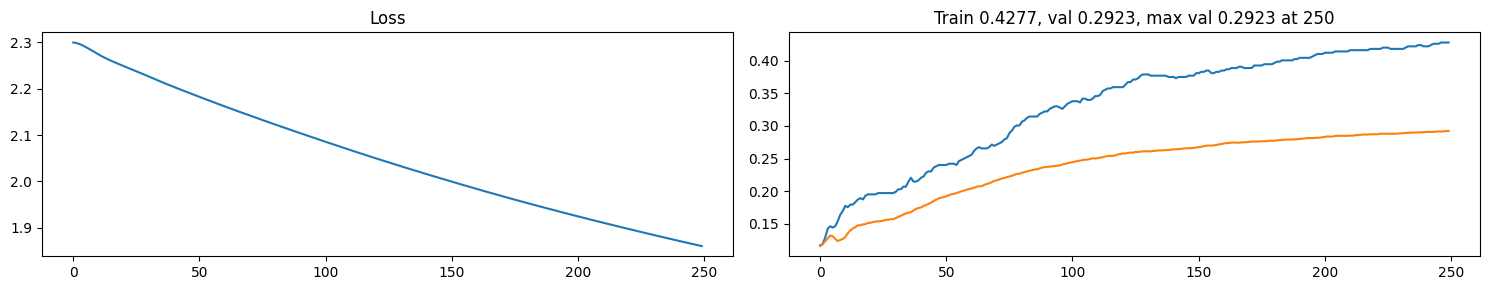

100%|██████████| 250/250 [08:10<00:00,  1.96s/it]


In [ ]:
set_random_seeds(device=device)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train_ob, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

model = MLP([3, 32, 32], 1000, 10)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

train(model, optimizer, loss_function, train_loader, val_loader, device, epochs_n=250)

## 2. Develop on subset
Firstly, we will select small subsets from the whole training and validation datasets to be able to quickly try different things.

For this we will use [torch.utils.data.Subset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset),
to which we pass the source dataset and a set of indices that select a subset.

In [ ]:
mnist_train = torchvision.datasets.MNIST(
    "./mnist", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

mnist_val = torchvision.datasets.MNIST(
    "./mnist", train=False, download=True, transform=torchvision.transforms.ToTensor()
)

In [ ]:
subset_size = 64
mnist_train_subset = torch.utils.data.Subset(mnist_train, torch.arange(subset_size))
mnist_val_subset = torch.utils.data.Subset(mnist_val, torch.arange(subset_size))

In [ ]:
# [0.1, 0.1, 0.1 ... ,0.6]

In [ ]:
# c(x) = argmax_y p(y|x)p(x) = argmax_y p(y|x) = argmax_y q(y|x)

Let's check that our subsets are not too small and still represent the original datasets.

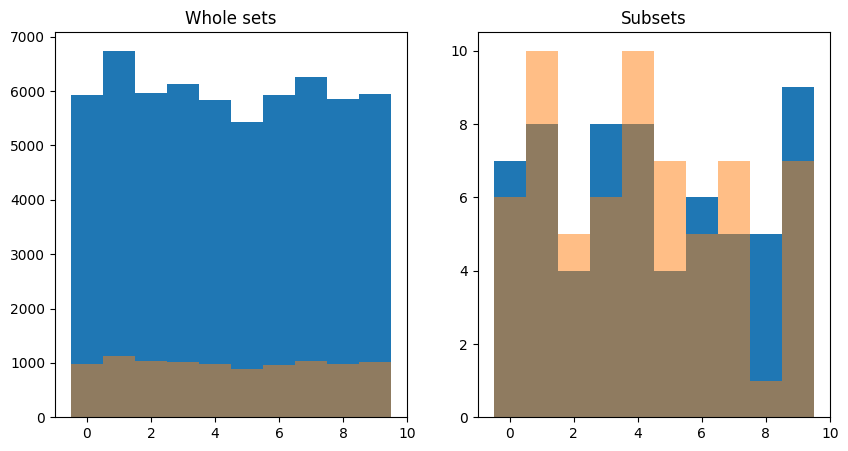

In [ ]:
_, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set_title("Whole sets")
ax[0].hist([target for _, target in mnist_train], bins=10, range=(-0.5, 9.5))
ax[0].hist([target for _, target in mnist_val], bins=10, range=(-0.5, 9.5), alpha=0.5)
ax[1].set_title("Subsets")
ax[1].hist([target for _, target in mnist_train_subset], bins=10, range=(-0.5, 9.5))
ax[1].hist(
    [target for _, target in mnist_val_subset], bins=10, range=(-0.5, 9.5), alpha=0.5
);

These subsets are bad --- they have a distribution of samples different from the full datasets.
But they are not awful, let's keep them and see what we can achieve.

Let's see how the model performs on these subsets.

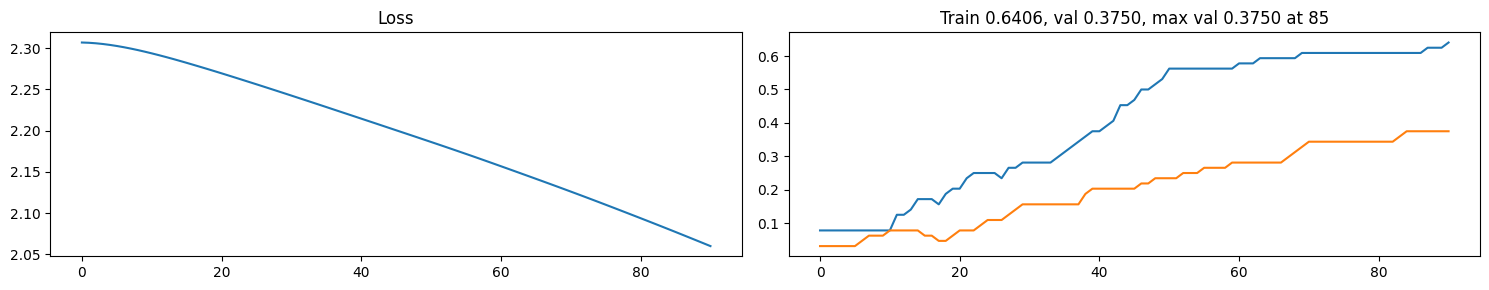

100%|██████████| 100/100 [02:05<00:00,  1.25s/it]


In [ ]:
set_random_seeds(device=device)

batch_size = 64
train_loader = torch.utils.data.DataLoader(
    mnist_train_subset, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    mnist_val_subset, batch_size=batch_size, num_workers=4
)

loss_function = torch.nn.CrossEntropyLoss()
model = MLP([1, 28, 28], 100, 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

First, based on the loss curve we see that the lerning rate is too small --- let's make it larger.

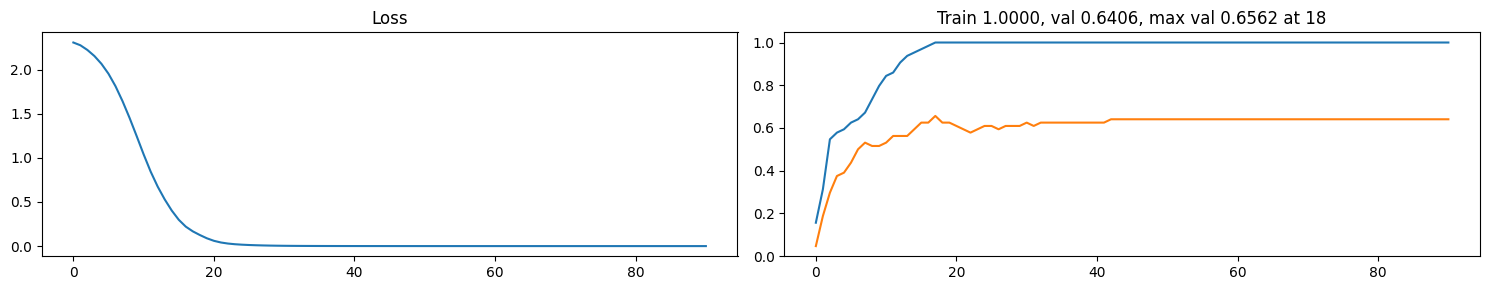

100%|██████████| 100/100 [02:02<00:00,  1.22s/it]


In [ ]:
set_random_seeds(device=device)

model = MLP([1, 28, 28], 100, 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

Second, we see that the model achieves perfect accuracy on the training set and, as expected, stops learning.
However, the accuracy on the validation set is low.
This is called overfitting: the model is not general and performs poorly on the data different from that it was trained on.
Let's try data augmentation to beat that.

обобщающая ошибка => оверфит, значит нужна регуляризация, первое будет добавим аугментацию данных

Почему не регуляризация L2?

## 3. Augment your data
Let's take a look at threes in our training and validation data.

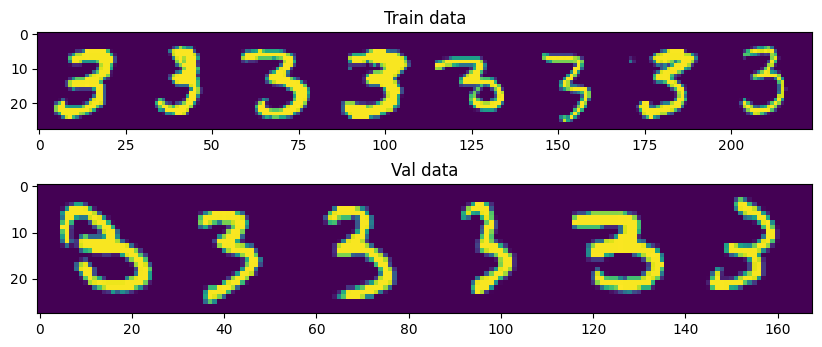

In [ ]:
f, ax = plt.subplots(2, figsize=(10, 4))
ax[0].set_title("Train data")
ax[1].set_title("Val data")
for x, y in train_loader:
    x = x[:, 0][y == 3]
    ax[0].imshow(np.hstack(x))
for x, y in val_loader:
    x = x[:, 0][y == 3]
    ax[1].imshow(np.hstack(x))

They are different, but not that different.
For example, the first three on the left from train and the second on the right from validation look pretty similar, as if one is a tilted version of the other.
So we can artificially expand the training data by randomly deforming the samples, e.g stretching, rotating them etc.
This is called data augmentation.

Let's try random rotations in the range of [-30, 30] degrees, random shears by [-30, 30] degrees, and random scaling by the factor 0.7 to 1.05 using the class [torchvision.transforms.RandomAffine](https://pytorch.org/docs/stable/torchvision/transforms.html?highlight=randomaffine#torchvision.transforms.RandomAffine).

In [ ]:
batch_size = 512

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomAffine(
            degrees=30, shear=30, scale=(0.7, 1.05)
        ),  # - > PIL
        torchvision.transforms.ToTensor(),  # PIL -> TENSOR!
    ]
)

mnist_train_augmented = torchvision.datasets.MNIST(
    "./mnist", train=True, download=True, transform=transform
)

mnist_train_subset = torch.utils.data.Subset(
    mnist_train_augmented, torch.arange(subset_size)
)
train_loader = torch.utils.data.DataLoader(
    mnist_train_subset, batch_size=batch_size, num_workers=4
)

Now we get infinite number of variations for each of our 64 train samples.

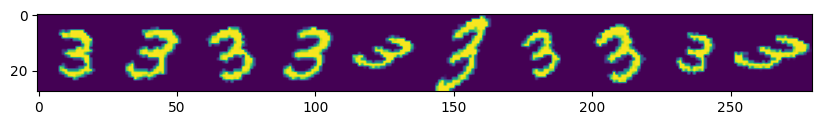

In [ ]:
augmentations = [mnist_train_subset[7][0][0] for i in range(10)]
plt.figure(figsize=(10, 10))
plt.imshow(np.hstack(augmentations))

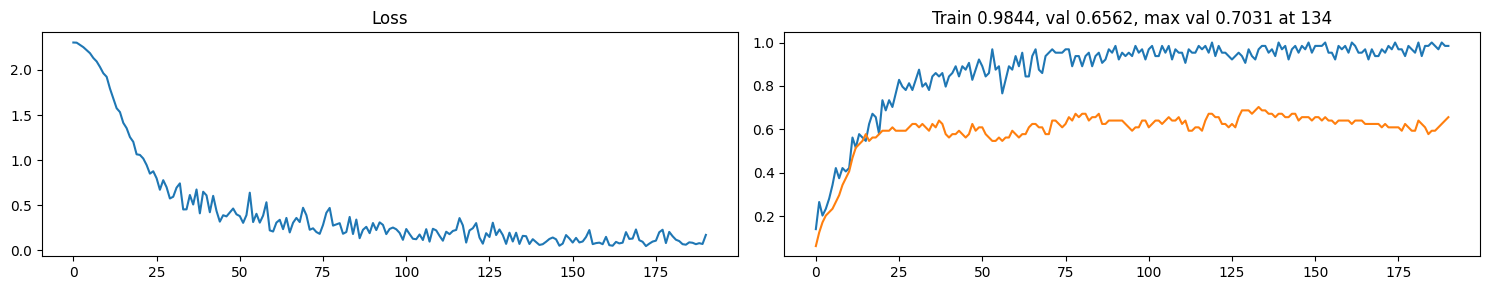

100%|██████████| 200/200 [04:05<00:00,  1.23s/it]


In [ ]:
set_random_seeds(device=device)

model = MLP([1, 28, 28], 100, 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=200,
    plot_each=10,
)

Now our model does not train that easily to the perfect train accuracy, but it still heavily overfits.
Let's try a different architecture.

попробовать регуляризацию l2 и дропаут

## 4. Use CNNs
Overfitting, in its essence, occurs when the model has a lot of trained parameters and can, basically, memorize the correct answers for the training data instead of learning to solve the task in general.
But simply reducing the number of trained parameters will most likely make the network weaker and reduce its performance.
Instead of simply reducing the number of parameters, it is better to constrain the family of functions that the network can represent via choosing the proper architecture, taking into account the nature of the task.

For processing of visual information, like images that we are working with today,
Convolutional Neural Networks, or simply CNNs, are the de-facto standard.
They are built upon two types of blocks, or layers --- convolutional layers and pooling layers.

Convolutions in CNNs look for some patterns in the input image or feature map.
For example, if we want to find this zero in the image

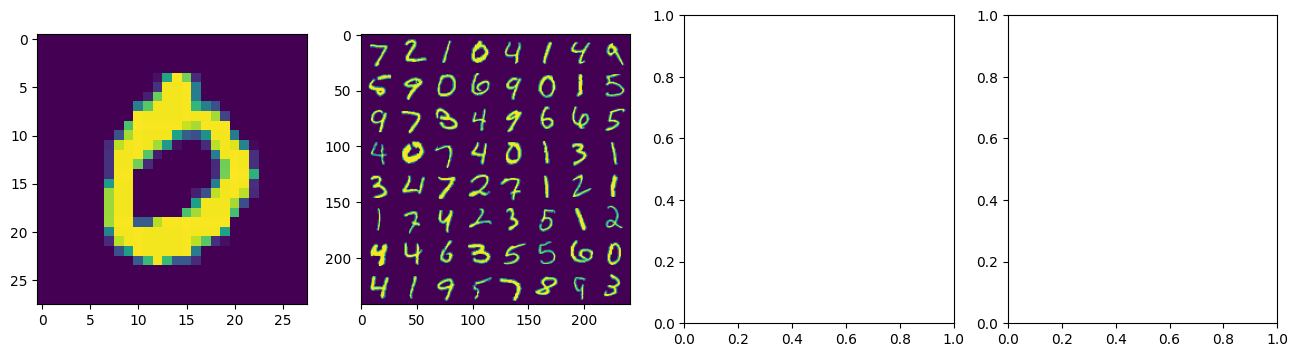

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

images_batch, _ = next(iter(val_loader))
images_grid = torchvision.utils.make_grid(images_batch, nrow=8)[:1]
ax[1].imshow(images_grid[0])

zero = mnist_val_subset[3][0]
ax[0].imshow(zero[0])

we can use a convolutionional layer [Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html?highlight=conv2d#torch.nn.Conv2d) with this zero as the kernel.

посмотреть где ноль проявляется, признаки

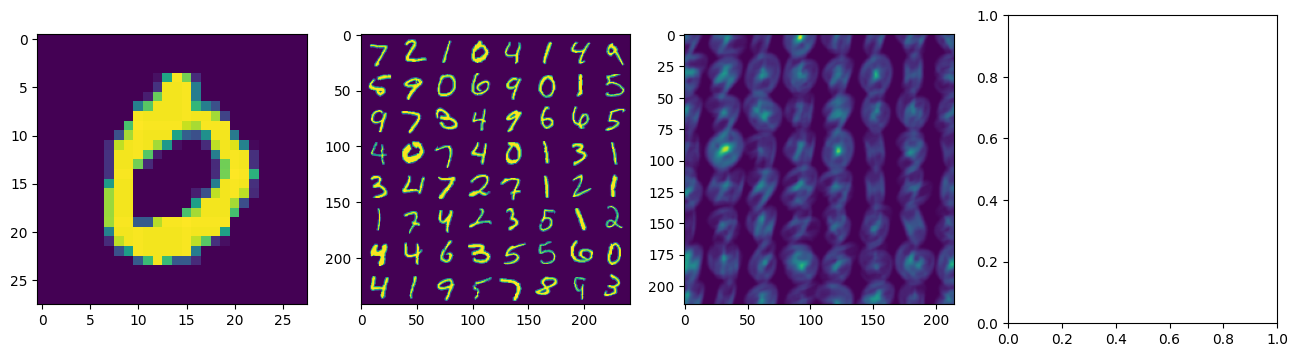

In [ ]:
conv = torch.nn.Conv2d(in_channels=1, out_channels=1, kernel_size=28, bias=False)
conv.weight.data[:] = zero

conv_out = conv(images_grid[None])

ax[2].imshow(conv_out.data[0, 0])
fig

The convolution slides its kernel, this zero, over the image and outputs the correlation of its kernel with a part of the image.

![](https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/no_padding_no_strides.gif)

The second basic block of CNNs, pooling layers, simply reduce the dimensions of the output,
which lowers the number of computations in the following layers and forces learning more representative kernels.

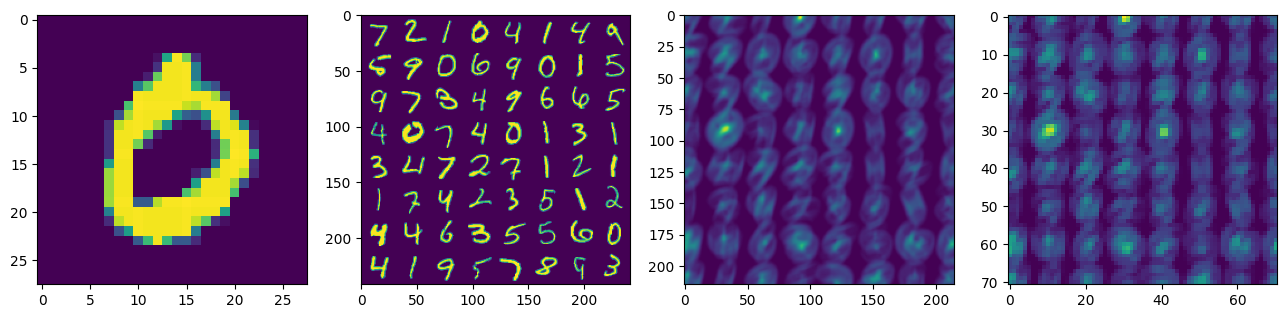

In [ ]:
pool = torch.nn.MaxPool2d(kernel_size=3)
pool_out = pool(conv_out)

ax[3].imshow(pool_out.data[0, 0])
fig

We will try a CNN similar in structure to [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).
It consists of two parts: a convolutional feature extractor and a fully-connected classifier.
![](https://github.com/adasegroup/ML2020_seminars/raw/master/seminar13/img/lenet.png)

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self, input_image_size, number_of_classes):
        super().__init__()
        in_channels, height, width = input_image_size

        # convolutional feature extractor
        self.stage1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels, out_channels=8, kernel_size=3, padding=1
            ),
            torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )  # -> feature maps 1-level from image

        #два слоя сверточный подряд 3x3 дает 5x5

        self.stage2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )  # -> feature maps 2-level: seek patterns from feature maps 1-level

        #

        # fully-connected classifier
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(16 * (height // 4) * (width // 4), 20),
            torch.nn.ReLU(),
            torch.nn.Linear(20, number_of_classes),
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.stage1(x)
        self.x_last = x.detach()# состояние x после 1 стадии
        x = self.stage2(x)
        x = x.reshape(batch_size, -1)
        x = self.fc(x)
        return x

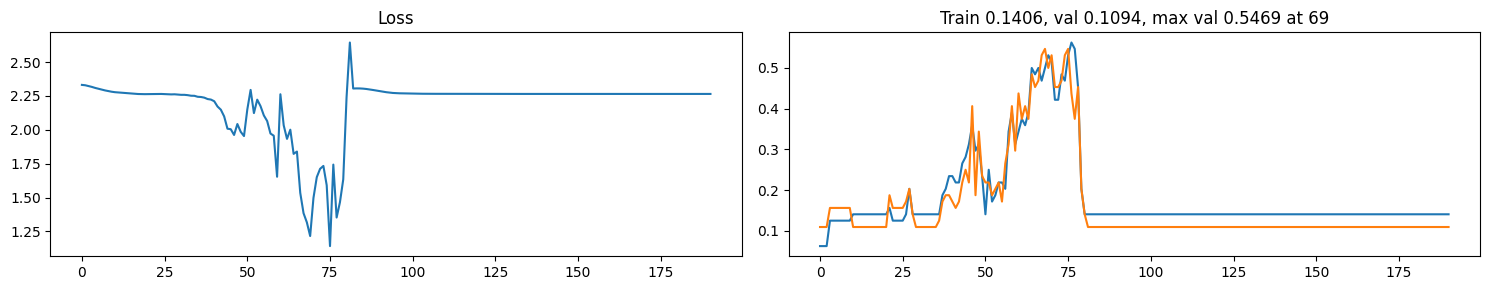

100%|██████████| 200/200 [05:07<00:00,  1.54s/it]


In [ ]:
set_random_seeds(device=device)

model = CNN([1, 28, 28], 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=200,
    plot_each=10,
)

сетка не обучаема

In [ ]:
def to_numpy(x):
    return x.detach().cpu().numpy()

что по x  в первом сверточном слое

(array([8.157e+04, 5.007e+03, 1.201e+03, 5.800e+01, 8.548e+03, 1.166e+03,
        1.164e+03, 8.840e+02, 5.090e+02, 2.450e+02]),
 array([0.        , 0.339196  , 0.67839199, 1.01758802, 1.35678399,
        1.69597995, 2.03517604, 2.37437201, 2.71356797, 3.05276394,
        3.39195991]),
 <BarContainer object of 10 artists>)

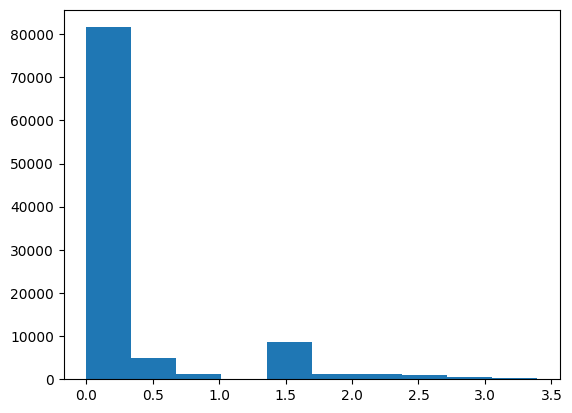

In [ ]:
plt.hist(to_numpy(model.x_last.flatten()))

In [ ]:
for batch in train_loader:
    break

(array([43425.,   515.,   415.,   341.,   400.,   417.,   390.,   427.,
          541.,  3305.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

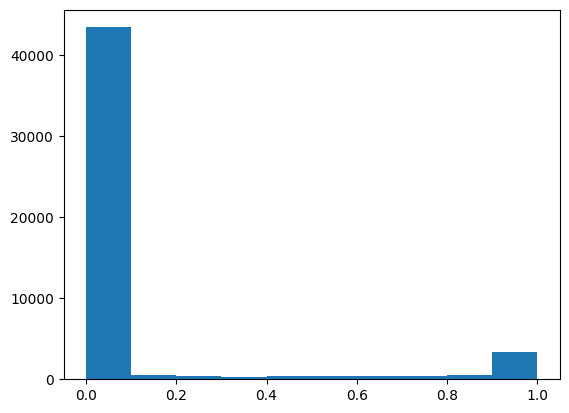

In [ ]:
plt.hist(batch[0].flatten())

почти все пиксели в батче имеют 0 значение

Now the training is unstable. Let's try Batch Normalization to counter this.

## 5. Use BatchNorm
Batch normalization, as the name implies, normalizes the input in the batch dimension.
It helps to reduce overfitting effects and stablizes training (see this [explanation by Ian Goodfellow](https://youtu.be/Xogn6veSyxA) on how Batch normalization helps training NNs).

Rougly speaking, we need to insert Batch Normalization layers between each pair of layers with trainable parameters.
In our case, this means that we add [BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html?highlight=batchnorm2d#torch.nn.BatchNorm2d) after each convolutional layer and [BatchNorm1d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html?highlight=batchnorm1d#torch.nn.BatchNorm1d) after the first linear layer.

In [ ]:
class CNNBN(torch.nn.Module):
    def __init__(self, input_image_size, number_of_classes):
        super().__init__()
        in_channels, height, width = input_image_size

        self.stage1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels, out_channels=8, kernel_size=3, padding=1
            ),
            torch.nn.BatchNorm2d(8),  ## <---out_channels=8
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(8),  ## <---
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.stage2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(16),  ## <---out_channels=16
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(16),  ## <---
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(16 * (height // 4) * (width // 4), 20),
            torch.nn.BatchNorm1d(20),  ## <---
            torch.nn.ReLU(),
            torch.nn.Linear(20, number_of_classes),
        )

    def forward(self, x):
        batch_size = x.shape[0]

        x = self.stage1(x)
        x = self.stage2(x)

        x = x.reshape(batch_size, -1)  #
        x = self.fc(x)
        return x

In [ ]:
model = CNNBN([1, 28, 28], 10)
model

CNNBN(
  (stage1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stage2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=784, out

In [ ]:
train_loader = torch.utils.data.DataLoader(
    mnist_train_subset, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    mnist_val_subset, batch_size=batch_size, num_workers=4
)

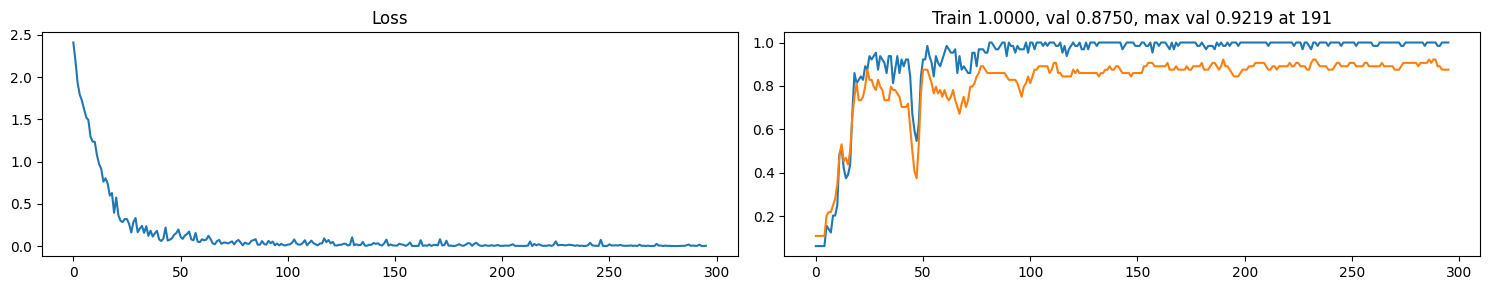

100%|██████████| 300/300 [07:50<00:00,  1.57s/it]


In [ ]:
set_random_seeds(device=device)

model = CNNBN([1, 28, 28], 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

loss_function = torch.nn.CrossEntropyLoss()
train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=300,
    plot_each=5,
)

We got a decent result taking into account that our training dataset consists of only 64 samples.
Let's see what else we can do.

We see that while the loss and train accuracy are relatively stable starting from 100-150 iterations, the validation accuracy jumps quite a lot.
This may be because of a too high learning rate.
If this is the case, we have, basically, two options to try to cope with this.

обобщающая ошибка уменьшилась, из-за регуляризации через батчнорм

## 6. Schedule your LR
It would be ideal to make several epochs with a large learning rate to approximately reach the optimum quickly,
and only then continue with a small learning rate to get to the optimum more accurately.
PyTorch provides [torch.optim.lr_scheduler](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) for this.

For example, we can use [torch.optim.lr_scheduler.MultiStepLR](https://pytorch.org/docs/stable/optim.html#torch.optim.lr_scheduler.MultiStepLR),
which decays the learning rate by a fixed factor `gamma` when the number of steps reaches certain `milestones`.

In [ ]:
model = CNNBN([1, 28, 28], 10)

optimizer = torch.optim.SGD(model.parameters(), lr=8)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=(20, 60, 100), gamma=1 / 2
)

# lrs = []
# for i in range(150):
#     # do the training stuff
#     # ...

#     lrs.append(optimizer.param_groups[0]['lr'])
#     scheduler.step()
# plt.plot(lrs)

We modify our training procedure to take scheduler as a parameter and do `scheduler.step()` at the end of each epoch.

In [ ]:
def train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=1,
    plot_each=1,
    scheduler=None,
):
    model = model.to(device)
    monitor = Monitor()
    for epoch in trange(epochs_n):
        model.train()
        for model_input, target in train_loader:
            model_input = model_input.to(device)
            target = target.to(device)
            model_output = model(model_input)
            loss = loss_function(model_output, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            monitor.add_loss_value(loss.item())

        model.eval()
        train_accuracy = get_accuracy(model, train_loader, device)
        val_accuracy = get_accuracy(model, val_loader, device)
        monitor.add_train_accuracy_value(train_accuracy)
        monitor.add_val_accuracy_value(val_accuracy)

        if epoch % plot_each == 0:
            monitor.show()

        if scheduler is not None:  ## <---
            scheduler.step()  ## <---

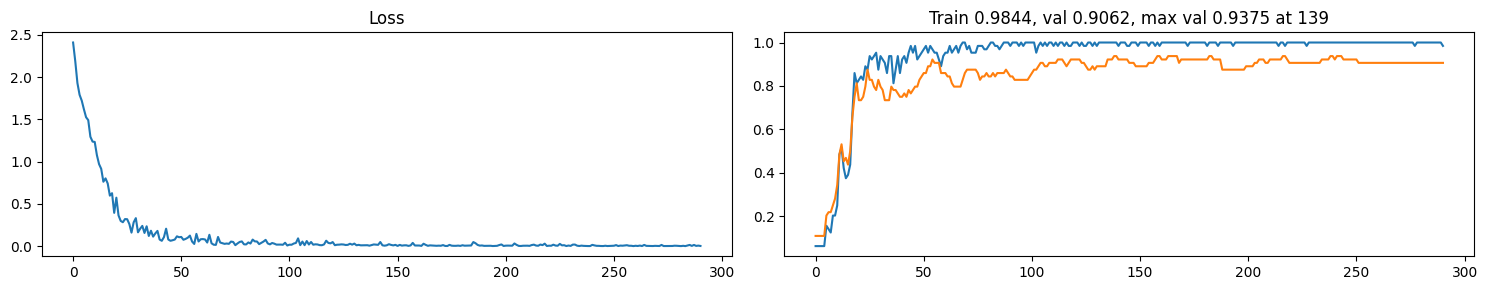

100%|██████████| 300/300 [07:46<00:00,  1.55s/it]


In [ ]:
set_random_seeds(device=device)

model = CNNBN([1, 28, 28], 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=(40, 150, 250), gamma=0.5
)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=300,
    plot_each=10,
    scheduler=scheduler,
)

Let's try training with learning rate 1e-1 for first 50 epochs,
and then decrease the learning rate by the factor of 2 once.

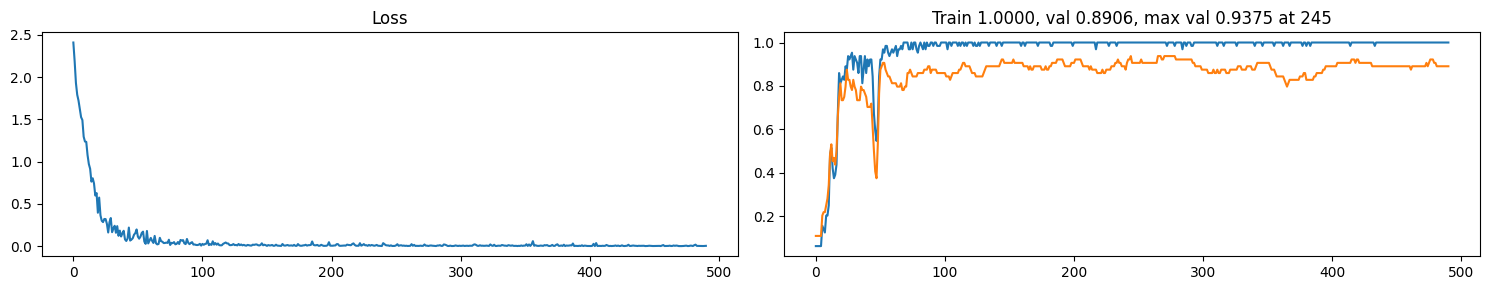

100%|██████████| 500/500 [12:54<00:00,  1.55s/it]


In [ ]:
set_random_seeds(device=device)

model = CNNBN([1, 28, 28], 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=(50,), gamma=0.5)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=500,
    plot_each=10,
    scheduler=scheduler,
)

LR scheduling made training a little bit more stable but did not improve the maximum validation accuracy.

## 7. Try a different optimizer

Another thing we could try is a different optimizer.
There is [a lot of them](https://ruder.io/optimizing-gradient-descent/), we will try [Adam](https://arxiv.org/pdf/1412.6980.pdf).
It adaptively scales the learning rate during the training for each individual parameter, and usually gives a decent performance with default parameters.

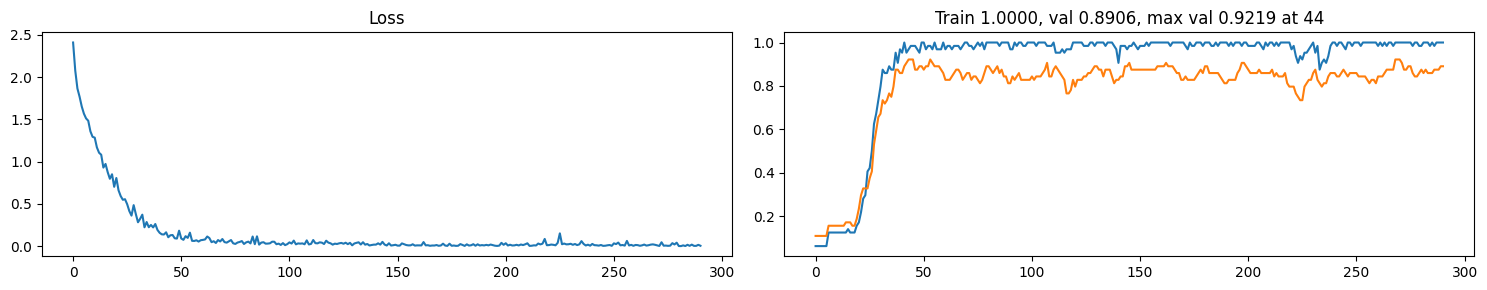

100%|██████████| 300/300 [08:27<00:00,  1.69s/it]


In [ ]:
set_random_seeds(device=device)

model = CNNBN([1, 28, 28], 10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)#можно меньше делать lr=1e-2

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=300,
    plot_each=10,
)

We get the same top performance as before.

## 8. Recap on CIFAR
### Exercise
Now try all these techniques for CIFAR.
Your goal is to get the best performance on validation set (while using only the train data for training of course).
Don't forget to set random seeds `seminar_utils.set_random_seeds(device=device)` before each initialization of the model to get reproducible results.

Start on a subset and see how different techniques help.
What else you could do to further improve the performance:
* use standart ML techniques such as cross-validation, ensembling, etc --- surely will help, but don't use it here
* [`Normalize`](https://pytorch.org/docs/stable/torchvision/transforms.html#torchvision.transforms.Normalize) the input --- may help, but may instead degrade the performance
* shuffle the training data using the `shuffle` parameter of `DataLoader`
* add $L_2$ regularization, aka weight decay, using the respective parameter of the optimizer or [`clamp`](https://pytorch.org/docs/stable/torch.html#torch.clamp) the weights directly --- unlikely will help since we already use BatchNorm (see e.g [this work](https://arxiv.org/abs/1706.05350))
* schedule learning rate more accurately --- most likely will help
* and, of course, STACK MORE LAYERS.

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=torchvision.transforms.ToTensor()
)
cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)

Files already downloaded and verified
Files already downloaded and verified


First, we select a data subset to debug our model on

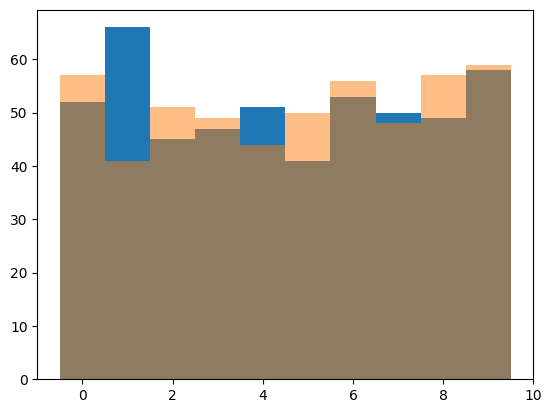

In [ ]:
subset_size = 512
cifar_train_subset = torch.utils.data.Subset(cifar_train, torch.arange(subset_size))
cifar_val_subset = torch.utils.data.Subset(cifar_val, torch.arange(subset_size))
plt.hist([target for _, target in cifar_train_subset], bins=10, range=(-0.5, 9.5))
plt.hist(
    [target for _, target in cifar_val_subset], bins=10, range=(-0.5, 9.5), alpha=0.5
);

First of all, we see that the performance is quite low for an MLP-based model

In [ ]:
batch_size = 64

In [ ]:
train_loader = torch.utils.data.DataLoader(
    cifar_train_subset, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val_subset, batch_size=batch_size, num_workers=4
)

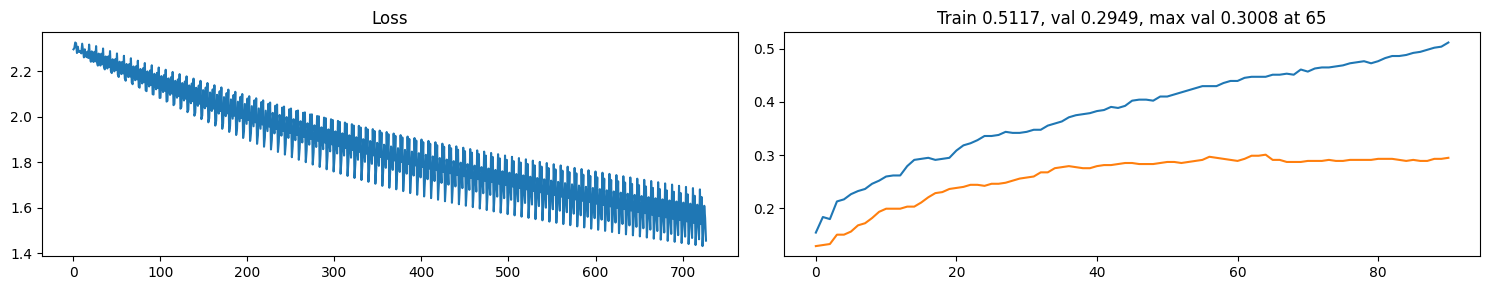

100%|██████████| 100/100 [02:49<00:00,  1.69s/it]


In [ ]:
set_random_seeds(device=device)

model = MLP([3, 32, 32], 100, 10)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

The default learning rate for SGD is low, let's try Adam.

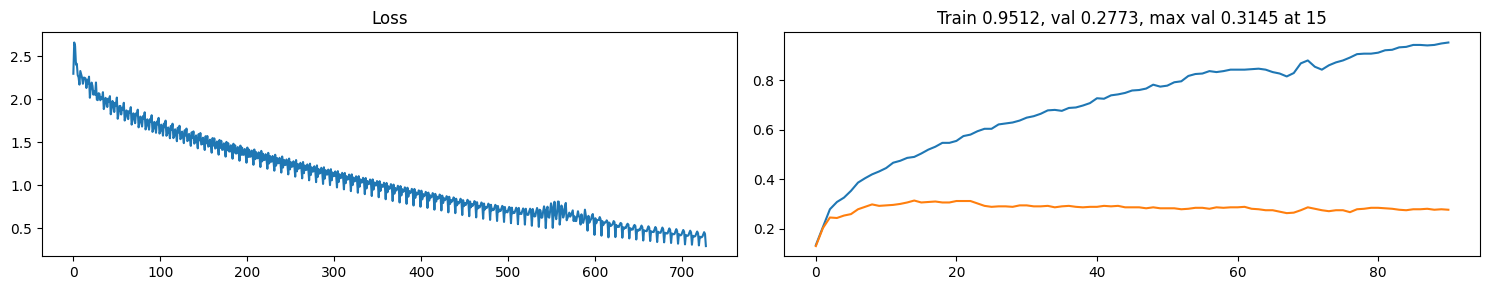

100%|██████████| 100/100 [02:41<00:00,  1.62s/it]


In [ ]:
set_random_seeds(device=device)

model = MLP([3, 32, 32], 100, 10)
optimizer = torch.optim.Adam(model.parameters())# у Adam базово lr=1e-1

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

Adam gives a nice performance, but the model overfits. Let's augment, but first, let's look at the input images.

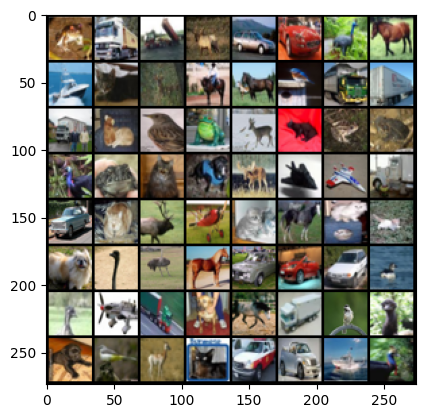

In [ ]:
for x, _ in train_loader:
    imgrid = torchvision.utils.make_grid(x, nrow=8)
    plt.imshow(imgrid.numpy().transpose(1, 2, 0))
    break

Let's try scaling and rotation as with MNIST, but remove shearing and add slight translation and horizontal flipping.

In [ ]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomAffine(
            degrees=15, scale=(0.7, 1.05), translate=(0.1, 0.1)
        ),
        torchvision.transforms.RandomHorizontalFlip(p=0.5),
        torchvision.transforms.ToTensor(),
    ]
)


cifar_train_subset = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10("./cifar", train=True, transform=transform),
    torch.arange(subset_size),
)

train_loader = torch.utils.data.DataLoader(
    cifar_train_subset, batch_size=batch_size, num_workers=4
)

Let's ensure that we didn't augment too much.

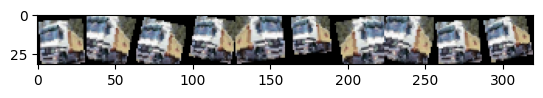

In [ ]:
augmentations = []
for _ in range(10):
    x, _ = cifar_train_subset[1]
    augmentations.append(x.permute(1, 2, 0))

plt.imshow(np.hstack(augmentations))

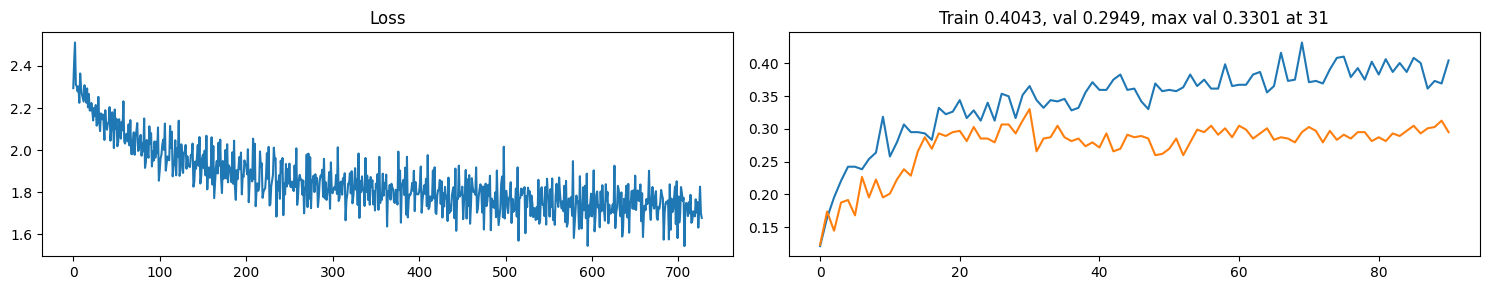

100%|██████████| 100/100 [02:49<00:00,  1.69s/it]


In [ ]:
set_random_seeds(device=device)

model = MLP([3, 32, 32], 100, 10)
optimizer = torch.optim.Adam(model.parameters())

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

Now, the performance is rather low, so let's try CNN with batch normalization.

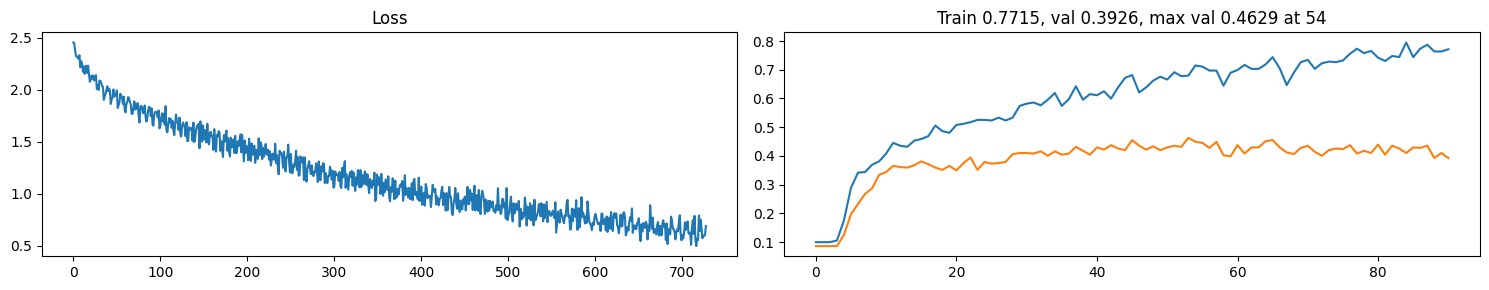

100%|██████████| 100/100 [02:48<00:00,  1.69s/it]


In [ ]:
set_random_seeds(device=device)

model = CNNBN([3, 32, 32], 10)
optimizer = torch.optim.Adam(model.parameters())

train(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    device,
    epochs_n=100,
    plot_each=10,
)

Better performance on train data but still quite bad performance on validation.

We may try more regularization techniques, like [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout), but at this moment it seems that we simply need more training data, since validation performance stops way before the train performance reaches it's peak.

Let's see how this setup performs when trained and validated on the whole dataset.

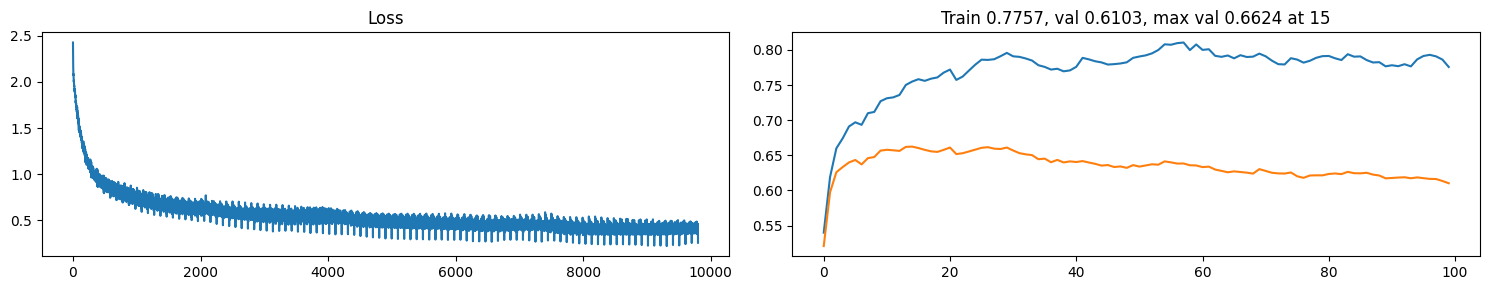

100%|██████████| 100/100 [08:42<00:00,  5.23s/it]


In [ ]:
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

set_random_seeds(device=device)

model = CNNBN([3, 32, 32], 10)
optimizer = torch.optim.Adam(model.parameters())

train(model, optimizer, loss_function, train_loader, val_loader, device, epochs_n=100)

# Fine-tuning

In [ ]:
model_ft = torchvision.models.resnet18(pretrained=True)# предобученая модель, resnet-18 самая маленькая
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = torch.nn.Linear(num_ftrs, 10)# голову меняем классификационную

/home/asarachakov/python10/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/asarachakov/python10/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
for name, parameter in model_ft.named_parameters():# (название слоя, атрибут параметра)
    if name.split(".")[0] != "fc":
        print(name, parameter.requires_grad)


# # model_ft.layer1[0].conv1.weight.requires_grad

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer3.0.conv1.weight True
layer3.0.bn1.weight True
layer3.0.bn1.bias True
layer3.0.conv2.weight True
layer3.0.bn2.weight True
layer3.0.bn2.bias True
layer3.0.downsample.0.weight True
layer3.0.downsample.1.weight True
layer3.0.downsample.1.bias True
la

In [ ]:
requires_grad()

In [ ]:
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
for batch, _ in train_loader:
    break

In [ ]:
model_ft(batch).shape

torch.Size([512, 10])

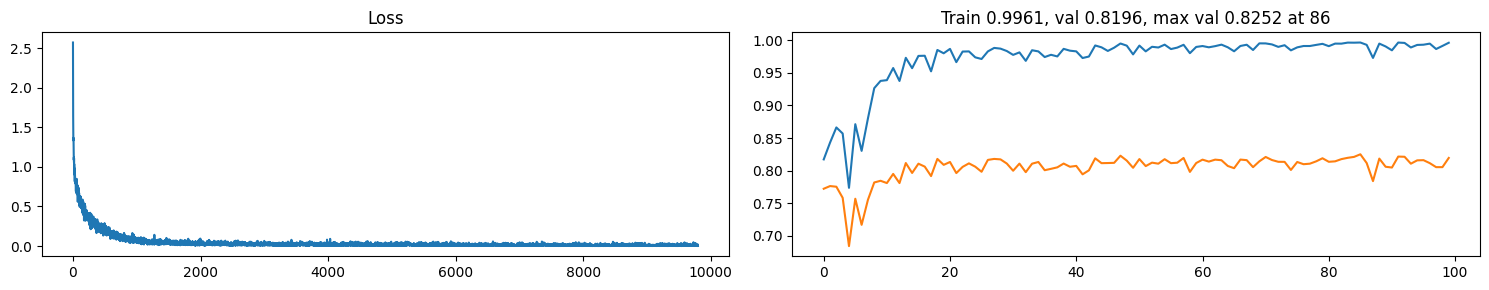

100%|██████████| 100/100 [09:27<00:00,  5.67s/it]


In [ ]:
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

set_random_seeds(device=device)
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-3)

train(
    model_ft, optimizer, loss_function, train_loader, val_loader, device, epochs_n=100
)

# Fine-tuning with augmentations

In [ ]:
model_ft = torchvision.models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = torch.nn.Linear(num_ftrs, 10)

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=transform
)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
for batch, _ in train_loader:
    break

In [ ]:
model_ft(batch).shape

torch.Size([512, 10])

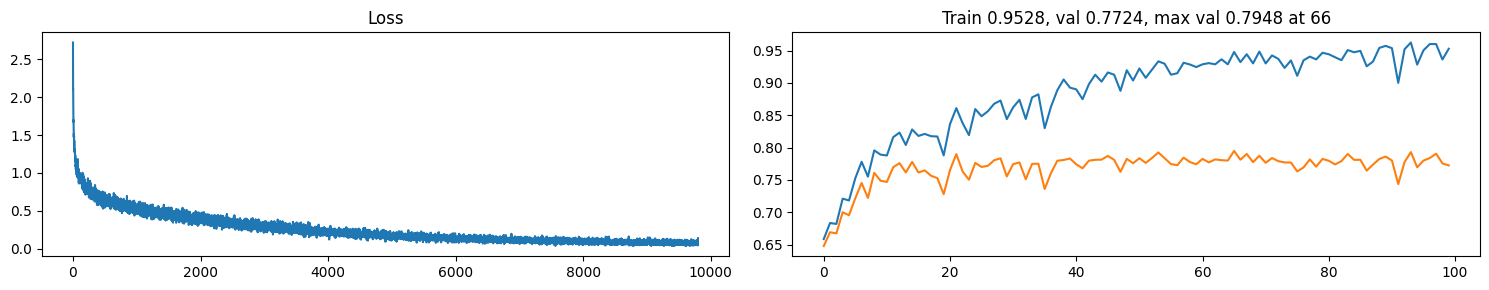

100%|██████████| 100/100 [15:27<00:00,  9.28s/it]


In [ ]:
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

set_random_seeds(device=device)
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-3)

train(
    model_ft, optimizer, loss_function, train_loader, val_loader, device, epochs_n=100
)

# Transfer learning

In [ ]:
model_ft = torchvision.models.resnet18(
    weights=torchvision.models.resnet.ResNet18_Weights.IMAGENET1K_V1
)# берем веса от предобученной модели, потому что resnet была обучена на IMAGENET1K_V1
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = torch.nn.Linear(num_ftrs, 10)

In [ ]:
for name, parameter in model_ft.named_parameters():
    if name.split(".")[0] != "fc":
        parameter.requires_grad = False#запрещаем обновлять веса всем слоям, кроме линейного слоя

In [ ]:
for name, parameter in model_ft.named_parameters():
    print(name, parameter.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=transform
)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
for batch, _ in train_loader:
    break

In [ ]:
model_ft(batch).shape

torch.Size([64, 10])

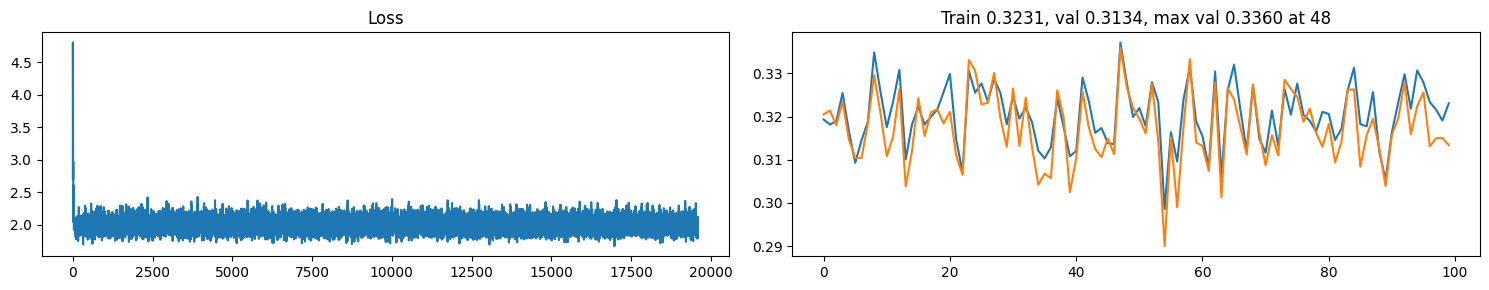

100%|██████████| 100/100 [14:37<00:00,  8.77s/it]


In [ ]:
batch_size = 256
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

set_random_seeds(device=device)
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-2, weight_decay=5e-6)

train(
    model_ft, optimizer, loss_function, train_loader, val_loader, device, epochs_n=100
)

значит не адаптированы самые верхние сверточные слои

# Full transfer learning

In [ ]:
model_ft = torchvision.models.resnet18(
    weights=torchvision.models.resnet.ResNet18_Weights.IMAGENET1K_V1
)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = torch.nn.Linear(num_ftrs, 10)

In [ ]:
for name, parameter in model_ft.named_parameters():
    if name.split(".")[0] not in ["layer4", "fc"]:
        parameter.requires_grad = False # выключаем градиенты у всех кроме ["layer4", "fc"]

In [ ]:
for name, parameter in model_ft.named_parameters():
    print(name, parameter.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=transform
)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
for batch, _ in train_loader:
    break

In [ ]:
model_ft(batch).shape

torch.Size([64, 10])

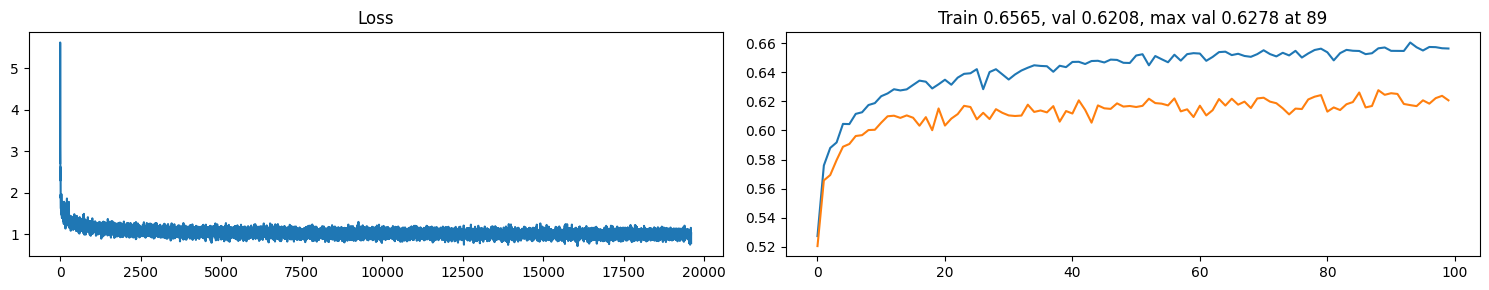

100%|██████████| 100/100 [15:29<00:00,  9.30s/it]


In [ ]:
batch_size = 256
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=4
)

set_random_seeds(device=device)
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-2, weight_decay=5e-6)

train(
    model_ft, optimizer, loss_function, train_loader, val_loader, device, epochs_n=100
)

# Final look of a model

In [ ]:
model_ft = torchvision.models.resnet50(
    weights=torchvision.models.resnet.ResNet50_Weights.IMAGENET1K_V2
)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = torch.nn.Linear(num_ftrs, 10)

разморозили всю сетку, мы обновляем все веса

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(
    "./cifar", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

cifar_val = torchvision.datasets.CIFAR10(
    "./cifar", train=False, download=True, transform=torchvision.transforms.ToTensor()
)

Files already downloaded and verified
Files already downloaded and verified


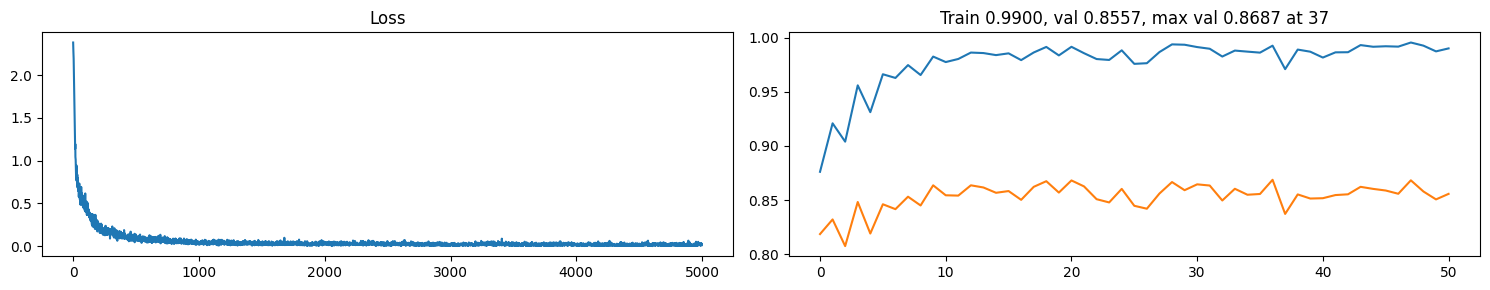

100%|██████████| 51/51 [07:42<00:00,  9.07s/it]


In [ ]:
batch_size = 512
train_loader = torch.utils.data.DataLoader(
    cifar_train, batch_size=batch_size, num_workers=6
)
val_loader = torch.utils.data.DataLoader(
    cifar_val, batch_size=batch_size, num_workers=6
)

set_random_seeds(device=device)
optimizer = torch.optim.Adam(model_ft.parameters(), lr=1e-3)

train(model_ft, optimizer, loss_function, train_loader, val_loader, device, epochs_n=51)

# Common guideline for DL model training



1. Ensure Data Cleanliness: It is crucial to thoroughly clean the data by ensuring consistent labeling, eliminating biases, and ensuring completeness.

2. Gain Data Understanding: Perform an Exploratory Data Analysis (EDA) to comprehend the data better. Analyze the data distributions, identify outliers, and investigate potential sources of data leakage or groups within the dataset.

3. Implement DataLoader: Develop a custom dataloader or utilize the dataloader provided by PyTorch to efficiently load and preprocess your data for training.

4. Train with a Reasonably Sized Model: Start training your model with a reasonably sized architecture. If you observe that the model's size is insufficient (indicated by a lack of decrease in loss during training), consider upgrading the model to a larger one.

5. Utilize Adam Optimizer.

6. Experiment with Model Modifications: Make alterations to the model architecture to explore different possibilities. For instance, you can replace the ReLU activation function with sigmoid and observe how it affects the model's performance. If the impact is not significant, it might indicate that either the model is too small or the data contains excessive noise. In such cases, it is advisable to clean the data once again.

7. Monitor Loss Curve and Adjust Learning Rate: Keep a close eye on the loss curve throughout training. Adjust the learning rate (LR) based on the curve's behavior, either by modifying it or maintaining it as is.

8. Use LR schedulers.

9. Perform Cross-Validation: Conduct cross-validation to evaluate the model's performance across different folds. The model's performance should exhibit consistency across these folds.

10. Address Generalization Error: If a significant difference arises between the training and validation datasets (indicating high generalization error), consider incorporating Dropout (p=0.5) or Batch Normalization techniques to mitigate overfitting.

11. Train Multiple Models and Compare: Train and compare approximately ten models to make an informed decision regarding the final model selection. Evaluating multiple models helps identify the best-performing one for your specific task.

12. Log Experiment Details: Maintain a log of your experiments to keep track of progress and make it easier to reproduce results. If you possess sufficient skills, consider using MLFlow for experiment tracking. Alternatively, create a new notebook, include a version number in its name, and provide a descriptive summary of the modifications made during each iteration. This practice promotes organization and facilitates collaboration or future improvements.


Обеспечьте чистоту данных: важно тщательно очистить данные — привести разметку к единообразию, устранить смещения (bias), проверить полноту.

Разберитесь в данных: выполните разведочный анализ данных (EDA), чтобы лучше понять датасет. Посмотрите распределения, найдите выбросы, проверьте возможные источники утечки данных (data leakage) и наличие групп/кластеров внутри данных.

Реализуйте DataLoader: сделайте свой загрузчик данных или используйте PyTorch DataLoader, чтобы эффективно загружать и предобрабатывать данные для обучения.

Обучайте модель разумного размера: начните с архитектуры среднего/разумного размера. Если видно, что модель слишком маленькая (например, loss почти не падает), попробуйте увеличить модель.

Используйте оптимизатор Adam.

Экспериментируйте с модификациями модели: меняйте архитектуру и проверяйте разные варианты. Например, замените ReLU на sigmoid и посмотрите, как это влияет на качество. Если изменений почти нет, это может означать, что модель слишком маленькая или в данных слишком много шума — тогда стоит снова вернуться к очистке данных.

Следите за кривой loss и корректируйте learning rate: внимательно наблюдайте за графиком функции потерь во время обучения и меняйте LR в зависимости от поведения кривой (уменьшайте/увеличивайте или оставляйте как есть).

Используйте планировщики learning rate (LR schedulers).

Сделайте кросс-валидацию: проведите cross-validation, чтобы оценить качество на разных фолдах. Результаты должны быть стабильными между фолдами.

Работайте с ошибкой обобщения: если между train и val наблюдается сильный разрыв (высокая ошибка обобщения), добавьте Dropout (p=0.5) или Batch Normalization, чтобы снизить переобучение.

Обучите несколько моделей и сравните: обучите и сравните примерно 10 моделей, чтобы выбрать финальную. Сравнение нескольких вариантов помогает найти лучший для вашей задачи.

Логируйте детали экспериментов: ведите журнал экспериментов, чтобы отслеживать прогресс и воспроизводить результаты. Если умеете — используйте MLflow для трекинга. Если нет — заведите отдельный ноутбук(и), добавляйте номер версии в название и кратко описывайте, что изменили в каждой итерации. Это помогает держать порядок и упрощает дальнейшую работу/улучшения.